# Step 2 — CUDA ESN + Ridge Regression (per-task UnifoLM suite)

Train a GPU Echo State Network to bridge **2 Hz VLA target tokens** → **100 Hz G1 joint tracking**.

**One task → one checkpoint folder** (so you can swap models by skill):

| Task | Checkpoint |
|------|------------|
| `wipe_table` (default / paper) | `models/esn_cuda_ridge/` |
| any other UnifoLM G1 task | `models/esn_cuda_ridge_<task_id>/` |

**Multi-episode (default):** 80/20 episode split (`train` / `heldout`). Wipe card: `results/step2_training/DATASET_CARD.md`.

Hyperparameter sweep uses the **first train episode**; final `W_out` is fit on **all** train episodes.

```bash
# single task (wipe, paper path)
python3 -m src.step2_esn_cuda_ridge --task wipe_table --train_episodes train --heldout_episodes heldout

# another skill
python3 -m src.step2_esn_cuda_ridge --task stack_block

# full single-embodiment suite (11 tasks; skips dual_clean_table)
python3 -m src.step2_esn_cuda_ridge --all_tasks --continue_on_error

# smoke
python3 -m src.step2_esn_cuda_ridge --tasks wipe_table,fold_towel --max_train_episodes 4 --max_heldout_episodes 2 --skip_sweep
```

Load later:
```python
from src.step2_esn_cuda_ridge import load_esn_for_task
esn = load_esn_for_task("wipe_table")  # or "clean_table", "stack_block", …
```


In [ ]:
from pathlib import Path
import os
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    RESEARCH_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "src" / "step2_esn_cuda_ridge.py").is_file():
    RESEARCH_DIR = NOTEBOOK_DIR
else:
    RESEARCH_DIR = NOTEBOOK_DIR / "research_summer_2026" / "research"
    if not RESEARCH_DIR.is_dir():
        RESEARCH_DIR = NOTEBOOK_DIR / "research"

RESEARCH_DIR = RESEARCH_DIR.resolve()
assert (RESEARCH_DIR / "src").is_dir(), f"src package not found under: {RESEARCH_DIR}"

os.chdir(RESEARCH_DIR)
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

from src.unifolm_tasks import esn_checkpoint_basename, list_esn_suite_tasks, print_task_table

print(f"Research root : {RESEARCH_DIR}")
print(f"Default wipe ckpt : {RESEARCH_DIR / 'models' / esn_checkpoint_basename('wipe_table')}")
print(f"Suite tasks ({len(list_esn_suite_tasks())}):")
print_task_table()


In [ ]:
# ── Task + multi-episode knobs ────────────────────────────────
# One skill at a time, or set TRAIN_ALL_TASKS=True for the full suite.
TASK_ID = "wipe_table"          # e.g. clean_table, stack_block, fold_towel, …
TRAIN_ALL_TASKS = False         # True → train ESN_SUITE_TASK_IDS (11 tasks)
TASK_LIST = None                # or ["wipe_table", "stack_block"] to override
# Smoke (fast): TRAIN_EPISODES_SPEC="0-7", HELDOUT_EPISODES_SPEC="160-163"
TRAIN_EPISODES_SPEC = "train"       # or "0-159" / "0-7"
HELDOUT_EPISODES_SPEC = "heldout"   # or "160-199" / "160-163"
MAX_TRAIN_EPISODES = None           # e.g. 16 for a quicker paper-dev pass
MAX_HELDOUT_EPISODES = None         # e.g. 8

RESERVOIR_SIZE = 1000
SPECTRAL_RADIUS = 0.95
SPARSITY = 0.90
LEAKY_RATE = 0.1
INPUT_SCALING = 1.0
RIDGE_ALPHA = 1e-2
WASHOUT = 50
SEED = 42
DEVICE = "cuda"

RUN_SWEEP = True
JERK_WEIGHT = 1.0
CONTINUE_ON_ERROR = True

from src.unifolm_tasks import (
    ESN_SUITE_TASK_IDS,
    esn_checkpoint_basename,
    get_task,
    list_esn_suite_tasks,
)
from src.wipe_dataset import TRAIN_EPISODES, HELDOUT_EPISODES

if TASK_LIST:
    TASK_IDS = list(TASK_LIST)
elif TRAIN_ALL_TASKS:
    TASK_IDS = list(ESN_SUITE_TASK_IDS)
else:
    TASK_IDS = [get_task(TASK_ID).id]

PRIMARY = get_task(TASK_IDS[0])
DATASET_ID = PRIMARY.primary_dataset_id
OUT_DIR_NAME = esn_checkpoint_basename(PRIMARY.id)

print(f"Tasks    : {TASK_IDS}")
print(f"Primary  : {PRIMARY.id} | unnorm={PRIMARY.unnorm_key}")
print(f"Dataset  : {DATASET_ID}")
print(f"Ckpt dir : models/{OUT_DIR_NAME}")
print(f"Canonical wipe: train={len(TRAIN_EPISODES)} heldout={len(HELDOUT_EPISODES)}")
print(f"Reservoir: N={RESERVOIR_SIZE} | rho={SPECTRAL_RADIUS} | sparsity={SPARSITY}")
print(f"Defaults : α_leak={LEAKY_RATE} | ridge λ={RIDGE_ALPHA} | sweep={RUN_SWEEP}")
print(f"Suite size: {len(list_esn_suite_tasks())} (excludes dual_clean_table)")


In [ ]:
import logging
from IPython.display import display
import pandas as pd

from src.paths import models_path, results_path
from src.step2_esn_cuda_ridge import (
    load_esn_for_task,
    run_training_for_task,
    write_multitask_summary,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

summaries = []
for tid in TASK_IDS:
    print("\n" + "#" * 72)
    print(f"# Training ESN for task={tid}")
    print("#" * 72)
    try:
        summary = run_training_for_task(
            tid,
            train_episodes_spec=TRAIN_EPISODES_SPEC,
            heldout_episodes_spec=HELDOUT_EPISODES_SPEC,
            max_train_episodes=MAX_TRAIN_EPISODES,
            max_heldout_episodes=MAX_HELDOUT_EPISODES,
            reservoir_size=RESERVOIR_SIZE,
            spectral_radius=SPECTRAL_RADIUS,
            sparsity=SPARSITY,
            leaky_rate=LEAKY_RATE,
            input_scaling=INPUT_SCALING,
            ridge_alpha=RIDGE_ALPHA,
            washout=WASHOUT,
            seed=SEED,
            device=DEVICE,
            skip_sweep=not RUN_SWEEP,
            jerk_weight=JERK_WEIGHT,
        )
        summaries.append(summary)
    except Exception as exc:
        logging.exception("Task %s failed: %s", tid, exc)
        summaries.append({"task_id": tid, "status": "error", "error": str(exc)})
        if not CONTINUE_ON_ERROR:
            raise

if len(summaries) > 1:
    paths = write_multitask_summary(summaries)
    print("Multi-task summary:", paths["csv"])

display(pd.DataFrame(summaries))
print("Registry:", models_path("esn_task_registry.json"))


In [ ]:
# Load the trained model for the skill you need
LOAD_TASK = TASK_IDS[0]
esn = load_esn_for_task(LOAD_TASK, device=DEVICE)
print(f"Loaded ESN for task={LOAD_TASK}")
print(f"  leak={esn.cfg.leaky_rate} ridge={esn.cfg.ridge_alpha} N={esn.cfg.reservoir_size}")
print(f"  checkpoint folder: models/{esn_checkpoint_basename(LOAD_TASK)}")

# Quick inference API reminder:
#   esn.update_vla_target(vla_joint_29d)   # ~2 Hz
#   cmd = esn.step_proprio(current_q_29d)  # 100 Hz


In [ ]:
# Held-out open-loop plots (wipe path): re-run the previous long-form viz cell
# from git history if needed, or:
#   python3 -m src.step2_esn_cuda_ridge --task wipe_table
# Results live under:
#   results/step2_training/esn_heldout_*.{csv,json}          (wipe)
#   results/step2_training/<task>/esn_heldout_*.{csv,json}   (other skills)
#   results/step2_training/esn_multitask_summary.csv
#   models/esn_task_registry.json
from pathlib import Path
import pandas as pd
summary_csv = Path("results/step2_training/esn_multitask_summary.csv")
if summary_csv.is_file():
    display(pd.read_csv(summary_csv))
else:
    print("No multitask summary yet — set TRAIN_ALL_TASKS=True or run --all_tasks on DGX.")


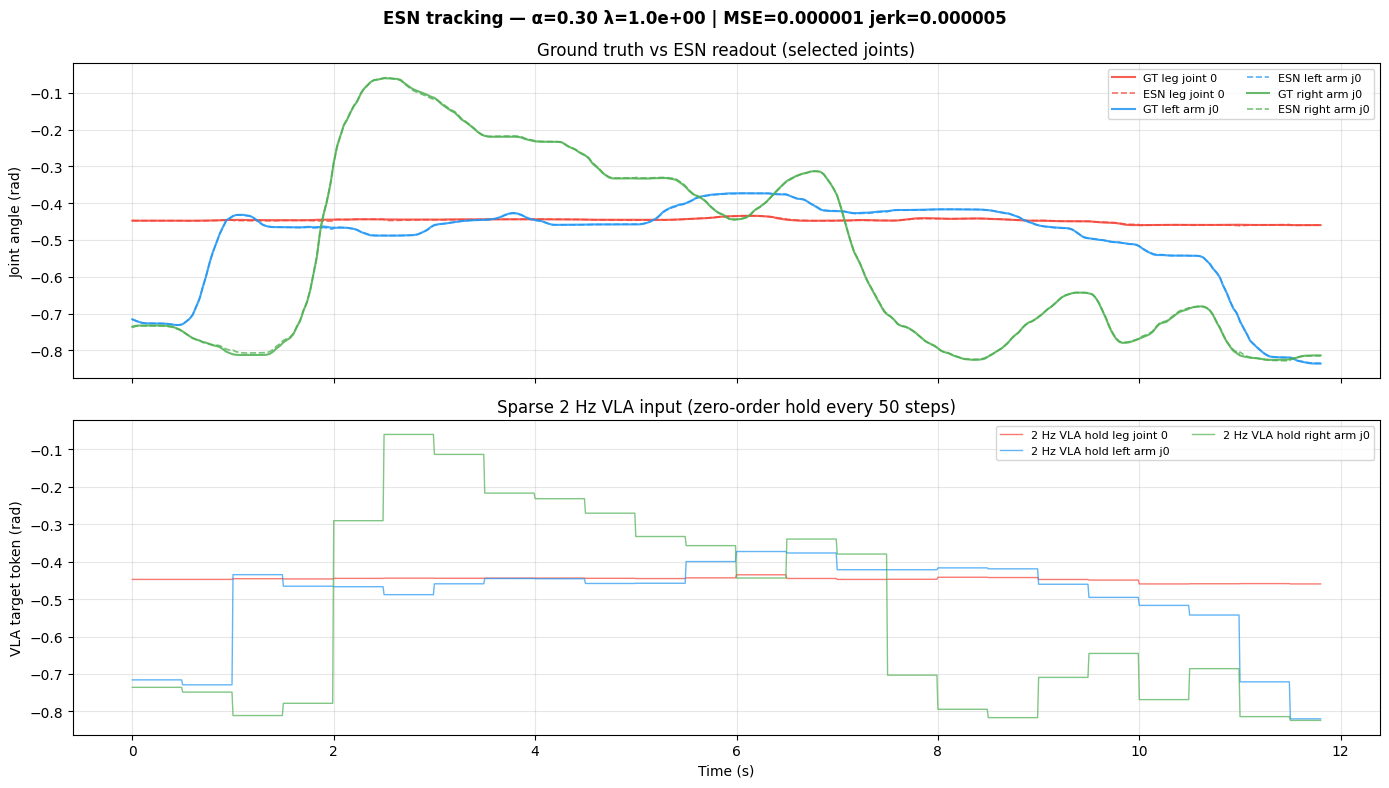

Figure saved: /home/aihimekpen/research_summer_2026/research/results/step2_training/esn_cuda_tracking.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

from src.paths import results_path

wo = esn.cfg.washout
with torch.no_grad():
    states = esn.collect_extended_states(joint_states, vla_targets)
    preds = predict_from_extended(esn.W_out, states).cpu().numpy()

tgt = ground_truth[wo:].cpu().numpy()
t_sec = np.arange(preds.shape[0]) / CONTROL_HZ
joint_ids = [0, 15, 22]  # leg, left arm, right arm
colors = ["#F44336", "#2196F3", "#4CAF50"]
labels = ["leg joint 0", "left arm j0", "right arm j0"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f"ESN tracking — α={metrics.get('leaky_rate', esn.cfg.leaky_rate):.2f} "
    f"λ={metrics.get('ridge_alpha', esn.cfg.ridge_alpha):.1e} | "
    f"MSE={metrics['mse']:.6f} jerk={metrics['jerk']:.6f}",
    fontsize=12,
    fontweight="bold",
)

ax = axes[0]
for j, color, label in zip(joint_ids, colors, labels):
    ax.plot(t_sec, tgt[:, j], color=color, lw=1.5, alpha=0.85, label=f"GT {label}")
    ax.plot(t_sec, preds[:, j], color=color, ls="--", lw=1.2, alpha=0.75, label=f"ESN {label}")
ax.set_ylabel("Joint angle (rad)")
ax.set_title("Ground truth vs ESN readout (selected joints)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

ax = axes[1]
vla_cpu = vla_targets[wo:].cpu().numpy()
for j, color, label in zip(joint_ids, colors, labels):
    ax.plot(t_sec, vla_cpu[:, j], color=color, lw=1.0, alpha=0.7, label=f"2 Hz VLA hold {label}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("VLA target token (rad)")
ax.set_title(f"Sparse 2 Hz VLA input (zero-order hold every {VLA_HOLD_STEPS} steps)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
out_dir = results_path("step2_training")
fig.savefig(out_dir / "esn_cuda_tracking.png", dpi=150, bbox_inches="tight")
fig.savefig(out_dir / "esn_cuda_tracking.pdf", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Figure saved: {out_dir / 'esn_cuda_tracking.png'}")